# Блок 5. Итоговое тестирование

## Описание блока:
В данном блоке будут обучены лучшие ML модели с подобранными гиперпараметрами для каждой группы датасетов. Подробное текстовое описания получившегося результата будет в  [Открыть тетрадку "Part 0"](Part%200.%20Research%20results.ipynb)

In [25]:
# импорт основных библиотек блока
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor

from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Добавляем родительскую директорию в sys.path
sys.path.append(os.path.abspath(".."))

from all_functions.datasets_load import load_all_datasets
from all_functions.datasets_transfom import *
from all_functions.func_for_ml import * 


In [26]:
# фиксация сида на будущее
RANDOM_STATE = 654321

In [27]:
# загрузка датасетов
crypt_Ethereum, crypt_BTC, futures_Brent_LCOK5, \
futures_WTI_CLJ5, share_metal_jiangxi_copper, \
share_metal_baoshan_iron, share_oil_petrochina_hk, \
share_oil_equinor_oslo, spot_preciouse_metal_AG, spot_preciouse_metal_AU = load_all_datasets()

In [28]:
# трансформация датасетов
crypt_Ethereum = transform_data(crypt_Ethereum)
crypt_BTC = transform_data(crypt_BTC)

futures_WTI_CLJ5 = transform_data(futures_WTI_CLJ5)
futures_Brent_LCOK5 = transform_data(futures_Brent_LCOK5)

share_metal_jiangxi_copper  = transform_data(share_metal_jiangxi_copper)
share_metal_baoshan_iron  = transform_data(share_metal_baoshan_iron)

share_oil_petrochina_hk  = transform_data(share_oil_petrochina_hk)
share_oil_equinor_oslo  = transform_data(share_oil_equinor_oslo)

spot_preciouse_metal_AU  = transform_data(spot_preciouse_metal_AU)
spot_preciouse_metal_AG = transform_data(spot_preciouse_metal_AG)

## Тестирование на тестовой выборке

In [29]:
def best_model_GradientBoostingRegressor(data, name, best_params):
    '''Функция по построению лучшей модели c использованием GradientBoostingRegressor'''
    
    line_length = 150
    print('-' * line_length)
    print(f'Тестирование датасета: {name}'.center(line_length))
    print('-' * line_length)

   # --- Разделение данных ---
    train_raw, valid_raw, test_raw = split_data(data)
    tail_len = 30

    train = upgrade_dataset(train_raw)
    valid = upgrade_dataset(valid_raw)
    test_with_tail = pd.concat([valid_raw.tail(tail_len), test_raw])
    test_with_tail = upgrade_dataset(test_with_tail)
    test = test_with_tail.loc[test_raw.index]

    X_train, y_train = return_x_y(train)
    X_test, y_test = return_x_y(test)
    
    # 4. Обучение модели
    model = GradientBoostingRegressor(**best_params)
    model.fit(X_train, y_train)
    
    # 5. Предсказание
    y_pred = model.predict(X_test)
    
    # 6. Оценка RMSE и MAPE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = round(mean_absolute_percentage_error(y_test, y_pred) * 100, 4)
    print(f"RMSE на тесте: {rmse:.4f}")
    print(f'MAPE на тесте: {mape}%')

    
    # 7. График
    plt.figure(figsize=(10, 5))
    plt.plot(y_test.index, y_test, label="Факт", color='blue')
    plt.plot(y_test.index, y_pred, label="Прогноз", color='orange')
    plt.title("прогноз и факт")
    plt.xlabel("Дата")
    plt.ylabel("Цена")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [30]:
def best_model_LGBM(data, name, best_params):
    '''Функция по построению лучшей модели c использованием GradientBoostingRegressor'''
    
    line_length = 150
    print('-' * line_length)
    print(f'Тестирование датасета: {name}'.center(line_length))
    print('-' * line_length)

   # --- Разделение данных ---
    train_raw, valid_raw, test_raw = split_data(data)
    tail_len = 30

    train = upgrade_dataset(train_raw)
    valid = upgrade_dataset(valid_raw)
    test_with_tail = pd.concat([valid_raw.tail(tail_len), test_raw])
    test_with_tail = upgrade_dataset(test_with_tail)
    test = test_with_tail.loc[test_raw.index]

    X_train, y_train = return_x_y(train)
    X_test, y_test = return_x_y(test)
    
    # 4. Обучение модели
    model = LGBMRegressor(**best_params, verbose = -1)
    model.fit(X_train, y_train)
    
    # 5. Предсказание
    y_pred = model.predict(X_test)
    
    # 6. Оценка RMSE и MAPE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = round(mean_absolute_percentage_error(y_test, y_pred) * 100, 4)
    print(f"RMSE на тесте: {rmse:.4f}")
    print(f'MAPE на тесте: {mape}%')
    
    # 7. График
    plt.figure(figsize=(10, 5))
    plt.plot(y_test.index, y_test, label="Факт", color='blue')
    plt.plot(y_test.index, y_pred, label="Прогноз", color='orange')
    plt.title("прогноз и факт")
    plt.xlabel("Дата")
    plt.ylabel("Цена")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Криптовалюты

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                        Тестирование датасета: crypt_Ethereum                                                         
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на тесте: 137.9873
MAPE на тесте: 3.7636%


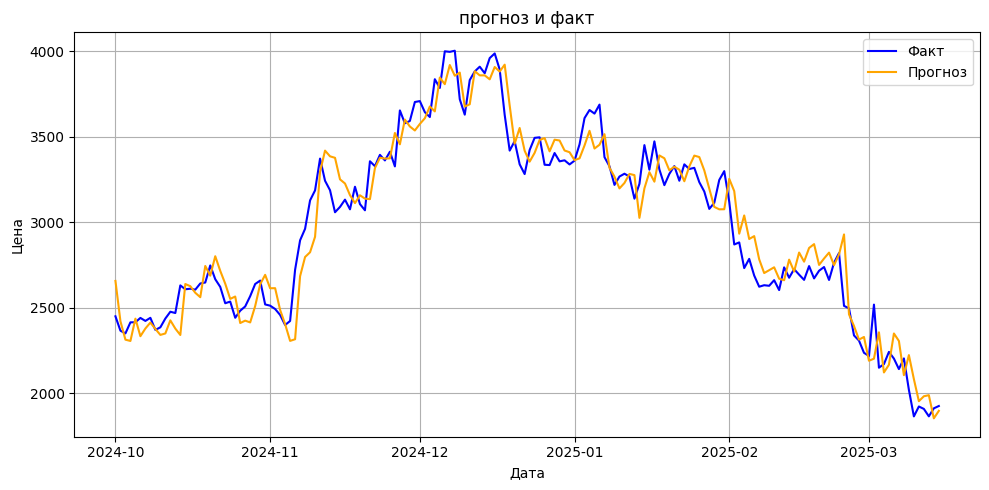

In [31]:
best_model_GradientBoostingRegressor(crypt_Ethereum, 'crypt_Ethereum', {'n_estimators': 239, 'learning_rate': 0.04063717639143676, 'max_depth': 4, 'subsample': 0.6303381907682958, 'min_samples_split': 7, 'min_samples_leaf': 5})

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                           Тестирование датасета: crypt_BTC                                                           
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на тесте: 28599.0817
MAPE на тесте: 26.6662%


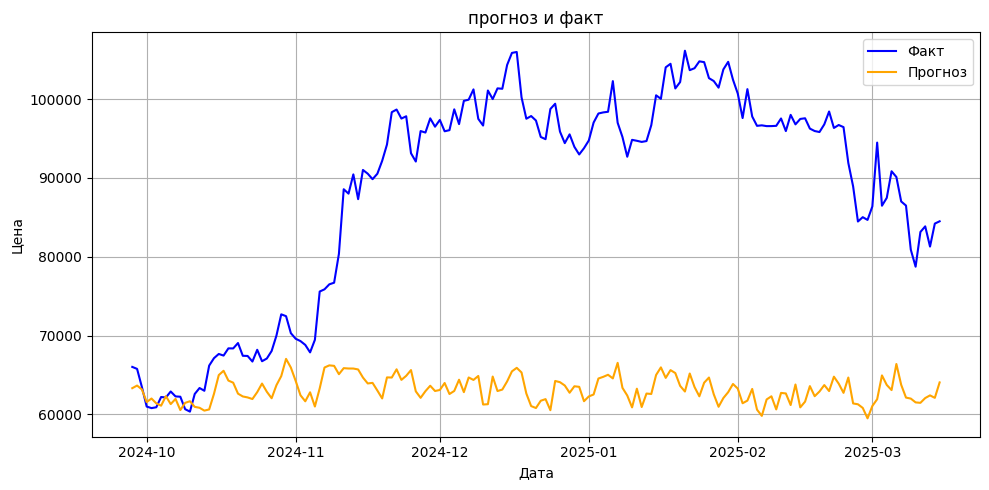

In [32]:
best_model_GradientBoostingRegressor(crypt_BTC, 'crypt_BTC', {'n_estimators': 271, 'learning_rate': 0.11575814816810856, 'max_depth': 3, 'subsample': 0.5834474426183737, 'min_samples_split': 8, 'min_samples_leaf': 4})

### Нефтеные фьючерсы

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                       Тестирование датасета: futures_WTI_CLJ5                                                        
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на тесте: 1.5255
MAPE на тесте: 1.7468%


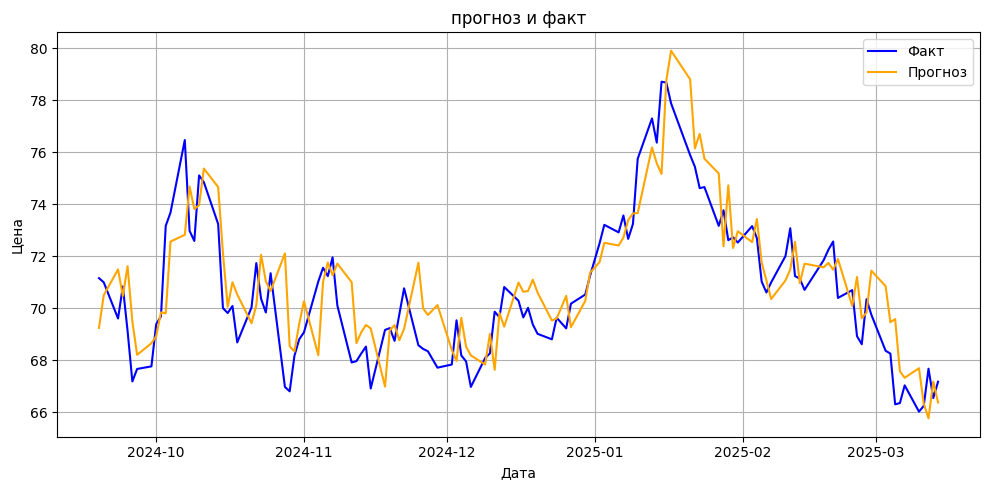

In [33]:
best_model_GradientBoostingRegressor(futures_WTI_CLJ5, 'futures_WTI_CLJ5', {'n_estimators': 131, 'learning_rate': 0.04657799151285184, 'max_depth': 5, 'subsample': 0.5026939851981022, 'min_samples_split': 10, 'min_samples_leaf': 2})

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                      Тестирование датасета: futures_Brent_LCOK5                                                      
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на тесте: 1.4326
MAPE на тесте: 1.5109%


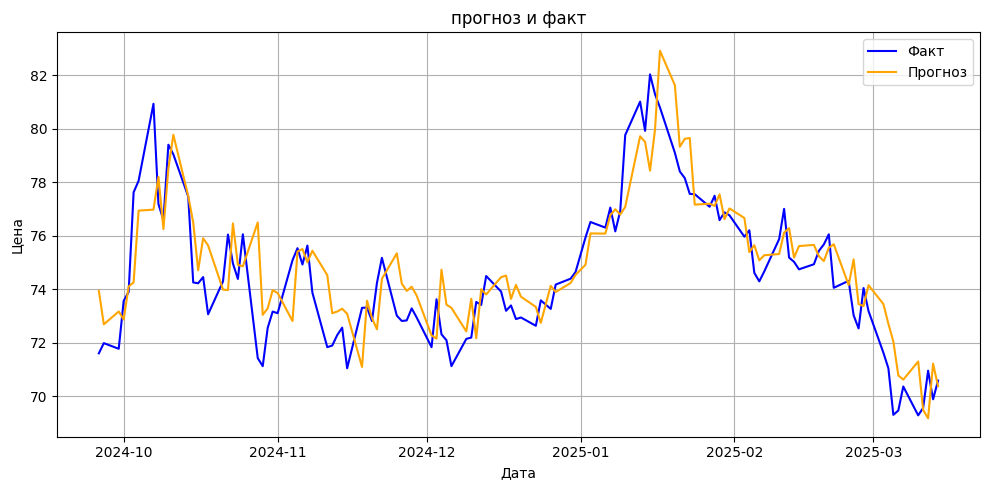

In [34]:
best_model_GradientBoostingRegressor(futures_Brent_LCOK5, 'futures_Brent_LCOK5', {'n_estimators': 297, 'learning_rate': 0.019697172771786824, 'max_depth': 5, 'subsample': 0.9105318359955741, 'min_samples_split': 10, 'min_samples_leaf': 3})

### Акции метталургических компаний

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                  Тестирование датасета: share_metal_jiangxi_copper                                                   
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на тесте: 0.4189
MAPE на тесте: 2.3304%


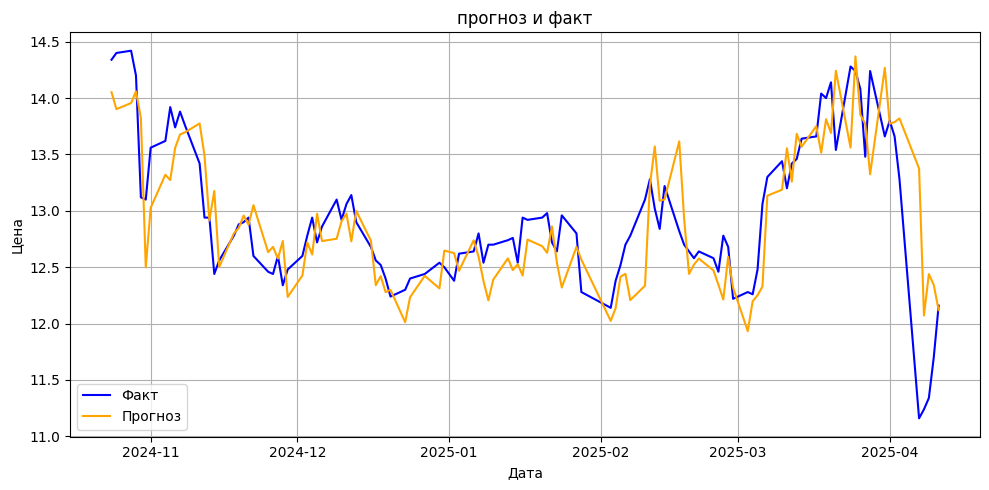

In [35]:
best_model_GradientBoostingRegressor(share_metal_jiangxi_copper, 'share_metal_jiangxi_copper', {'n_estimators': 259, 'learning_rate': 0.0394105112768372, 'max_depth': 5, 'subsample': 0.552561648631057, 'min_samples_split': 6, 'min_samples_leaf': 4})

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                   Тестирование датасета: share_metal_baoshan_iron                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на тесте: 0.1668
MAPE на тесте: 1.9382%


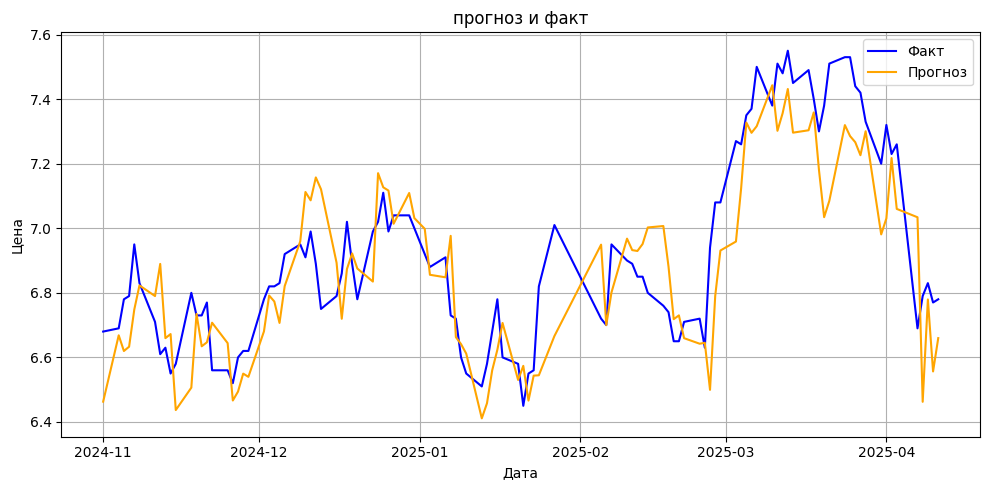

In [36]:
best_model_GradientBoostingRegressor(share_metal_baoshan_iron, 'share_metal_baoshan_iron', {'n_estimators': 156, 'learning_rate': 0.06267709307510576, 'max_depth': 4, 'subsample': 0.5035597846532046, 'min_samples_split': 6, 'min_samples_leaf': 5})

### Акции нефтедобывающих компаний

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                    Тестирование датасета: share_oil_petrochina_hk                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на тесте: 0.6703
MAPE на тесте: 10.5486%


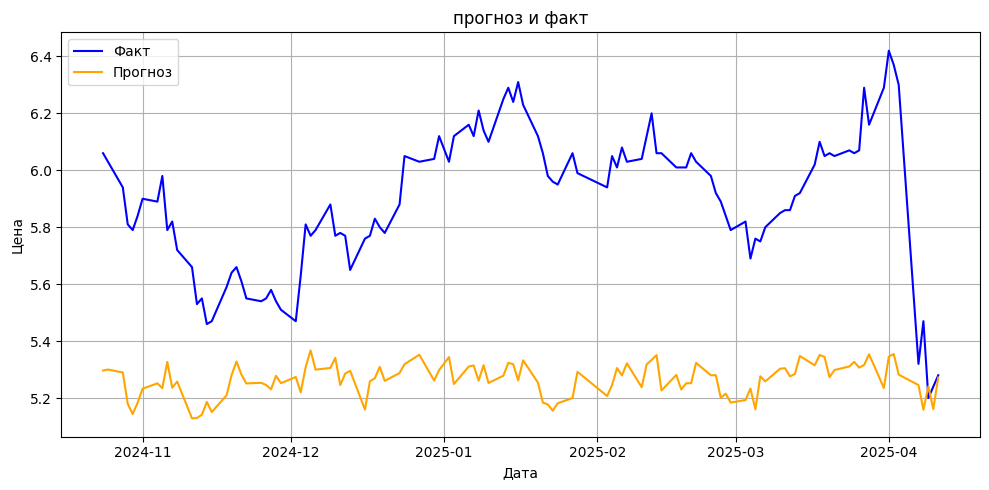

In [37]:
best_model_LGBM(share_oil_petrochina_hk, 'share_oil_petrochina_hk', {'n_estimators': 153, 'learning_rate': 0.054276399679638106, 'max_depth': 7, 'num_leaves': 136, 'min_child_samples': 22})

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                    Тестирование датасета: share_oil_equinor_oslo                                                     
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на тесте: 8.0008
MAPE на тесте: 2.4814%


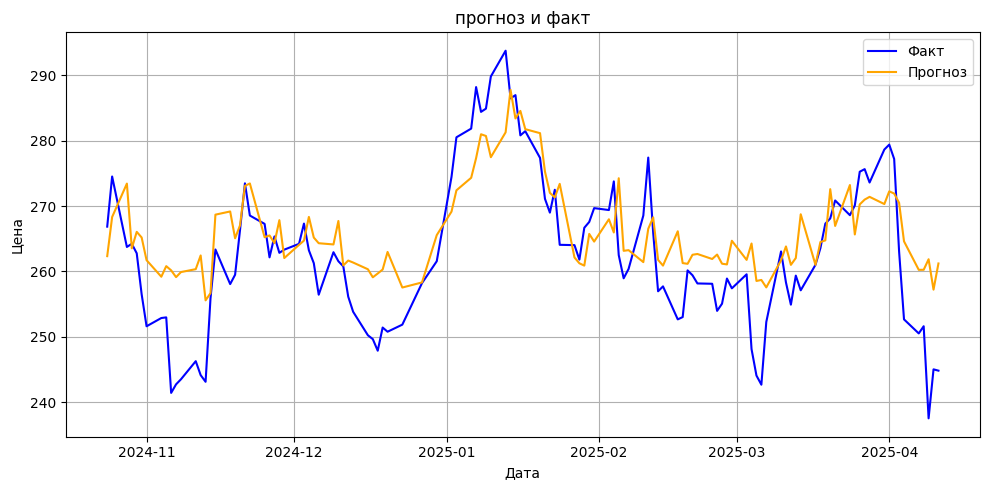

In [38]:
best_model_LGBM(share_oil_equinor_oslo, 'share_oil_equinor_oslo', {'n_estimators': 148, 'learning_rate': 0.022906413238095946, 'max_depth': 5, 'num_leaves': 73, 'min_child_samples': 22})

### Спотовы цена на драгоценные металы

In [39]:
class DeepLSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):  # x: [batch, seq_len, features]
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # последний шаг
        return out.squeeze(1)


In [40]:
class SlidingWindowDataset(Dataset):
    def __init__(self, X, y, seq_len=10):
        self.X_seq = []
        self.y = []

        for i in range(len(X) - seq_len):
            self.X_seq.append(X.iloc[i:i+seq_len].values)
            self.y.append(y.iloc[i+seq_len])

        self.X_seq = torch.tensor(self.X_seq, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.y[idx]

In [41]:
class TunedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(1)

In [44]:
def best_model_LSTM(data, name, lstm_params, seq_len=15, epochs=50):
    '''
    Построение и оценка лучшей LSTM модели
    data — исходный датафрейм
    name — имя датасета
    lstm_params — словарь с параметрами LSTM: hidden_size, num_layers, dropout, lr
    '''
    from torch.utils.data import DataLoader
    import torch.nn as nn

    line_length = 150
    print('-' * line_length)
    print(f'LSTM: Тестирование датасета: {name}'.center(line_length))
    print('-' * line_length)

    # --- Разделение ---
    train_raw, valid_raw, test_raw = split_data(data)
    tail_len = 30

    train = upgrade_dataset(train_raw)
    test_with_tail = pd.concat([valid_raw.tail(tail_len), test_raw])
    test_with_tail = upgrade_dataset(test_with_tail)
    test = test_with_tail.loc[test_raw.index]

    X_train, y_train = return_x_y(train)
    X_test, y_test = return_x_y(test)

    # --- Масштабирование ---
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = pd.DataFrame(scaler_X.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler_X.transform(X_test), columns=X_test.columns)

    y_train_scaled = pd.Series(scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten())
    y_test_scaled = pd.Series(scaler_y.transform(y_test.values.reshape(-1, 1)).flatten())

    # --- Dataset ---
    train_ds = SlidingWindowDataset(X_train_scaled, y_train_scaled, seq_len)
    test_ds = SlidingWindowDataset(X_test_scaled, y_test_scaled, seq_len)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=32)

    # --- Модель ---
    class LSTMModel(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers, dropout):
            super().__init__()
            self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                                num_layers=num_layers, dropout=dropout, batch_first=True)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :]).squeeze(1)

    model = LSTMModel(
        input_size=X_train.shape[1],
        hidden_size=lstm_params["hidden_size"],
        num_layers=lstm_params["num_layers"],
        dropout=lstm_params["dropout"]
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lstm_params["lr"])
    criterion = nn.MSELoss()

    # --- Обучение ---
    model.train()
    for epoch in range(epochs):
        for x_batch, y_batch in train_loader:
            output = model(x_batch)
            loss = criterion(output, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # --- Предсказание ---
    model.eval()
    y_preds = []
    with torch.no_grad():
        for x_batch, _ in test_loader:
            pred = model(x_batch)
            y_preds.extend(pred.numpy())

    # --- Обратная нормализация
    y_preds_rescaled = scaler_y.inverse_transform(np.array(y_preds).reshape(-1, 1)).flatten()
    y_test_rescaled = scaler_y.inverse_transform(y_test_scaled.values[seq_len:].reshape(-1, 1)).flatten()

    #  Оценка RMSE и MAPE
    rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_preds_rescaled))
    mape = round(mean_absolute_percentage_error(y_test_rescaled, y_preds_rescaled) * 100, 4)
    print(f"RMSE на тесте: {rmse:.4f}")
    print(f'MAPE на тесте: {mape}%')
    
    # --- График
    plt.figure(figsize=(10, 5))
    idx = y_test.index[seq_len:]
    plt.plot(idx, y_test_rescaled, label="Факт", color="blue")
    plt.plot(idx, y_preds_rescaled, label="Прогноз", color="orange")
    plt.title(f"LSTM Прогноз для {name}")
    plt.xlabel("Дата")
    plt.ylabel("Цена")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                 LSTM: Тестирование датасета: spot_preciouse_metal_AG                                                 
------------------------------------------------------------------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2908311773478998 and num_layers=1
  warnings.warn(


RMSE на тесте: 3.0028
MAPE на тесте: 8.9913%


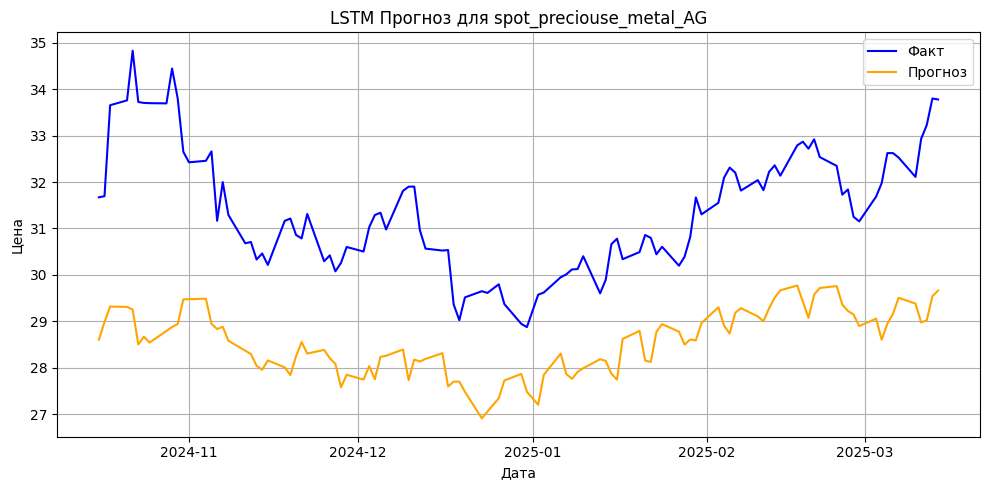

In [45]:
best_model_LSTM(spot_preciouse_metal_AG, 'spot_preciouse_metal_AG',  {'hidden_size': 219, 'num_layers': 1, 'dropout': 0.2908311773478998, 'lr': 0.0015684231181917073, 'seq_len': 6})

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                 LSTM: Тестирование датасета: spot_preciouse_metal_AU                                                 
------------------------------------------------------------------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.17053855163576737 and num_layers=1
  warnings.warn(


RMSE на тесте: 575.3111
MAPE на тесте: 20.493%


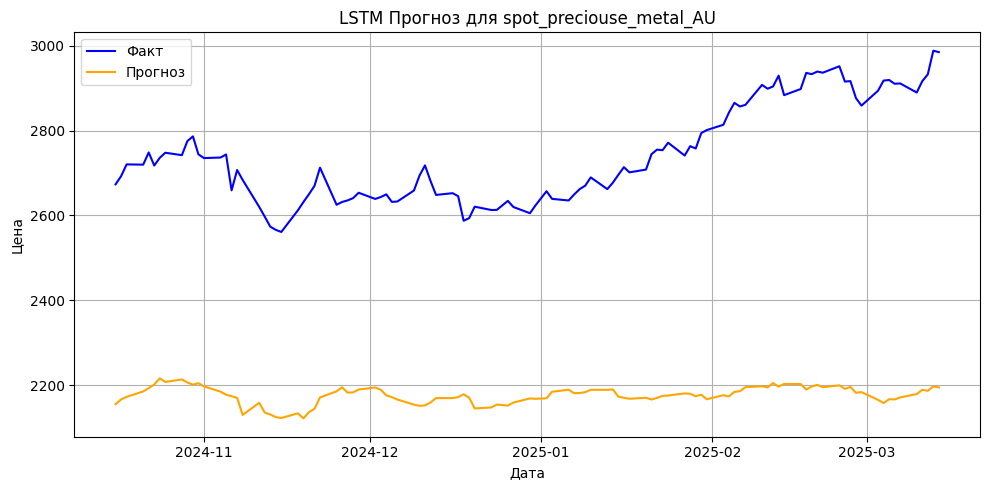

In [46]:
best_model_LSTM(spot_preciouse_metal_AU, 'spot_preciouse_metal_AU',  {'hidden_size': 157, 'num_layers': 1, 'dropout': 0.17053855163576737, 'lr': 0.0001086892714804816, 'seq_len': 16})